# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Lukas Vrouwenvelder

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Lab Overview and Submission

**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.

### Part 1: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern.

### Part 2: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [3]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [4]:
X #this is the song count matrix, with each row representing a song and each column representing a word in the vocabulary. The values in the matrix indicate the count of each word in the corresponding song.

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 11.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  3.,  0.,  0.],
       [ 0.,  0.,  0., ...,  2.,  0.,  0.]], shape=(8000, 800))

In [5]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
63,what,6
26,it,6
21,here,6
20,have,6
41,our,5
54,through,5


In [6]:
# define results csv
export_csv = "./data/top_40_songs_by_genre_results.csv"

# match based on track id
top_40_song_indices = songs[songs["track_id"].isin(top_40["track_id"])].index
# new df to put results in 
results_df = songs.loc[top_40_song_indices, meta_cols].copy()

# #Sanity check 
# results_df.shape


In [7]:
# reusable features for cleaner chunks later. 


def get_top_3_within_genre(scores, query_idx):
    """Find the 3 highest-scoring songs w/in the genre as the query song"""
    query_genre = songs.loc[query_idx, "genre"]
    is_same_genre = songs["genre"] == query_genre # variable is a bool
    is_query_song = songs.index == query_idx  # so is this one 

    scores_to_rank = np.array(scores, dtype=float).copy()
    scores_to_rank[~is_same_genre | is_query_song] = -np.inf  # rule out other genres and self (pass the bool)

    best_3 = np.argsort(scores_to_rank)[::-1][:3] #return an index for sorting instead of sorting 
    return [(song_idx, scores_to_rank[song_idx]) for song_idx in best_3]


def add_calculation_to_results(query_idx, calculation_name, top_3_matches):
    """Record one calculation's top-3 matches for one query song as 6 new columns (includes raw calc value)"""
    for rank, (match_idx, score) in enumerate(top_3_matches, start=1): 
        song_label = f"{songs.loc[match_idx, 'artist_name']} - {songs.loc[match_idx, 'song_title']}"
        results_df.loc[query_idx, f"{calculation_name}_rank{rank}_song"] = song_label
        results_df.loc[query_idx, f"{calculation_name}_rank{rank}_score"] = score

    results_df.to_csv(export_csv, index=False)


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [8]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


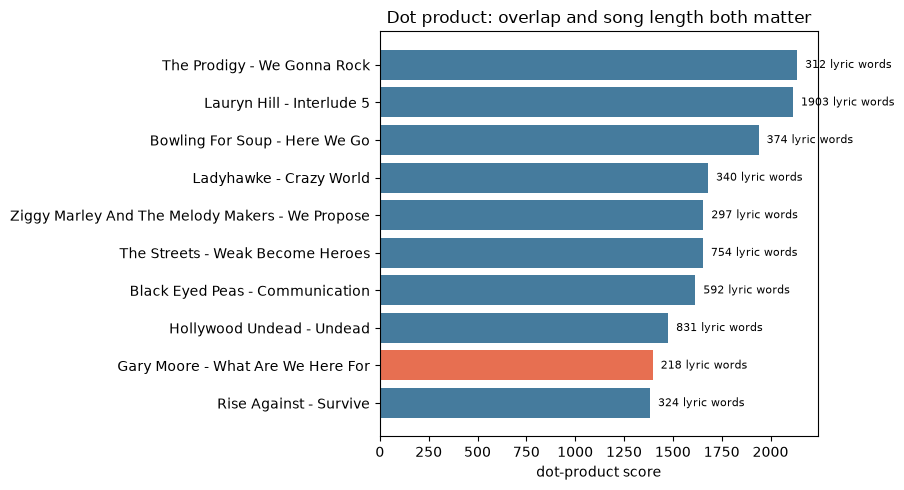

In [9]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

No, these are not strong matches. Song length is playing a large factor in match (dot product) strength. 

The results are influenced by the size of the song, which impacts the number of times that a certain word shows up. The dot product is taken off the matrix of the summation of any given word, so, if we took a long song - let's say a sung version of Lord of the Rings - it would contain a lot of word matches, and the sum of matching words would be very high. The sung book would be the number one match for practically any song based on sheer word volume. 

In [10]:
#pull all genres from 'genre' column in top_40 dataset
genres = top_40['genre'].unique()
genres

<ArrowStringArray>
[     'blues',  'classical',    'country', 'electronic',       'folk',
    'hip hop',       'jazz',      'latin',      'metal',        'pop',
       'punk',   'r&b/soul',     'reggae',       'rock']
Length: 14, dtype: str

In [11]:
# create export copy of top_40
top_40_results = top_40.copy()

In [12]:
# Dot chunk

for query_idx in results_df.index:
    query_vector = X[query_idx]
    dot_scores = X @ query_vector

    top_3 = get_top_3_within_genre(dot_scores, query_idx)
    add_calculation_to_results(query_idx, "dot", top_3)

results_df.filter(like="dot").head()


,dot_rank1_song,dot_rank1_score,dot_rank2_song,dot_rank2_score,dot_rank3_song,dot_rank3_score
9,The Isley Brothers - Touch Me,1007.0,Charley Patton - Shake It And Break It,1003.0,K-Ci & JoJo - Baby Come Back,974.0
27,Robin Trower - Day Of The Eagle,1291.0,The Isley Brothers - Touch Me,1206.0,Lemar - The Way Love Goes,902.0
33,The Isley Brothers - Touch Me,728.0,Lemar - The Way Love Goes,642.0,Susan Tedeschi - Loving You Is Sweeter Than Ever,636.0
55,Janis Joplin - Kozmic Blues,588.0,The Isley Brothers - Touch Me,576.0,K-Ci & JoJo - Baby Come Back,561.0
60,Lemar - The Way Love Goes,2836.0,Avant - I Wanna Know,2620.0,Susan Tedeschi - Loving You Is Sweeter Than Ever,2513.0


## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [13]:
# where the actual covariance scores are computed, using the centered dot product and the standard deviations of the query and song vectors

query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)



,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2064.18000,2.580225
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1856.78500,2.320981
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,1767.24000,2.209050
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1617.63000,2.022038
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1599.53625,1.999420
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1516.73875,1.895923
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1510.34125,1.887927
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1352.34875,1.690436
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1313.77875,1.642223
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1312.27875,1.640348


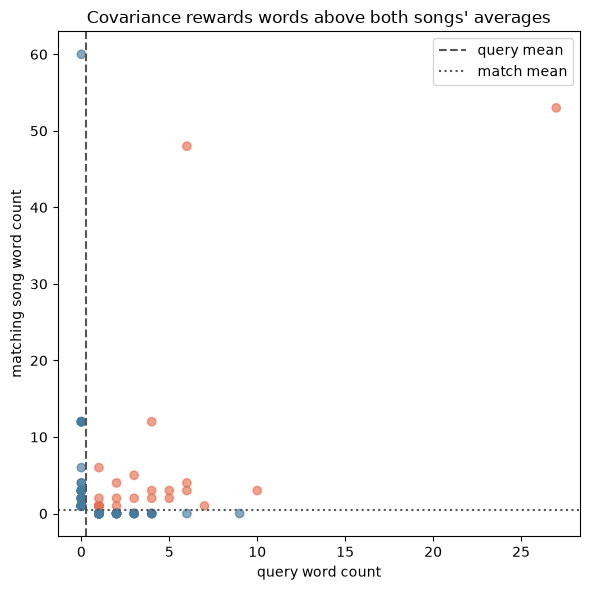

In [14]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Lauren Hill's lengthy 'Interlude 5' moved down the rankings a spot, making way for BFS's 'Here We Go.' The top-5 remains otherwise unchanged. 

The new covarience score is an expression of how far off each individual word count is off from the song's average word count. This creates more of a relative comparison of 'shape' more than actual matching. As an economist, I think of this as 'relative word advantage' for each song. This should actually favor songs with a few, repetitive lyrics, as these large word counts will have a bigger diffeerntial to the average of the song. Their relative advatage will be the heavily repeated lyric, thus influencing it's profile. Comparing profiles rather than raw word counts may help match common themes / lyrics more effectively. 

In [15]:
# Centered dot chunk

for query_idx in results_df.index:
    query_vector = X[query_idx]
    query_centered = query_vector - query_vector.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)
    centered_dot_scores = X_centered @ query_centered

    top_3 = get_top_3_within_genre(centered_dot_scores, query_idx)
    add_calculation_to_results(query_idx, "centered_dot", top_3)

results_df.filter(like="centered_dot").head()


,centered_dot_rank1_song,centered_dot_rank1_score,centered_dot_rank2_song,centered_dot_rank2_score,centered_dot_rank3_song,centered_dot_rank3_score
9,Charley Patton - Shake It And Break It,915.79500,The Isley Brothers - Touch Me,885.36125,K-Ci & JoJo - Baby Come Back,873.14375
27,Robin Trower - Day Of The Eagle,1178.35250,The Isley Brothers - Touch Me,1088.83875,Lemar - The Way Love Goes,826.83625
33,The Isley Brothers - Touch Me,665.31500,Lemar - The Way Love Goes,601.78500,Susan Tedeschi - Loving You Is Sweeter Than Ever,600.82500
55,Janis Joplin - Kozmic Blues,552.01000,The Isley Brothers - Touch Me,531.97125,K-Ci & JoJo - Baby Come Back,524.49375
60,Lemar - The Way Love Goes,2732.11125,Avant - I Wanna Know,2533.47125,The Blues Brothers - Everybody Needs Somebody ...,2423.28500


## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [16]:
def correlation_scores(matrix, query_vector):
    """Correlation: covariance rescaled by each vector's own standard deviation."""
    query_centered = query_vector - query_vector.mean()
    matrix_centered = matrix - matrix.mean(axis=1, keepdims=True)
    centered_dot = matrix_centered @ query_centered
    covariance = centered_dot / matrix.shape[1]

    query_std = query_vector.std()  # calculates the standard deviation of the query vector -> normalize the covariance scores when computing the correlation scores.
    matrix_std = matrix.std(axis=1)  # matrix_std is the standard deviation of each song vector in the dataset, computed along axis 1 rows

    denom = matrix_std * query_std
    return np.divide(covariance, denom, out=np.zeros_like(covariance), where=denom != 0)


corr_scores = correlation_scores(X, query)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)


,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.755614
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.746012
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.728089
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.698025
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.696568
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.684930
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.684267
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.679579
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.678728


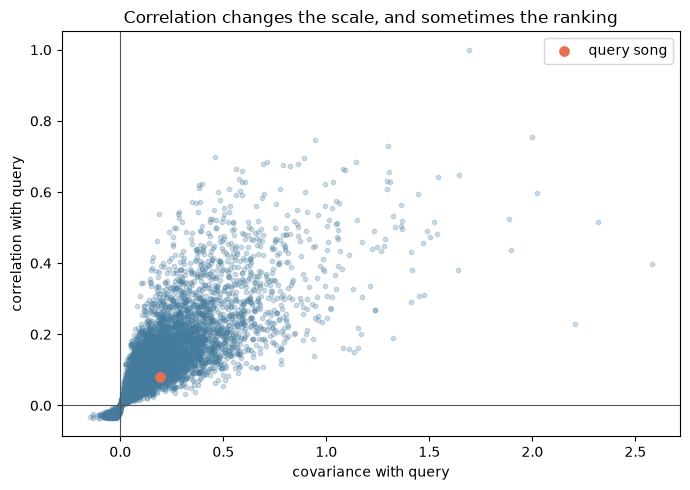

In [17]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Songs that have a high standard deviation (a wide distribution of words) will see their correlation drop, and their ranking fall as a result. As covarience is divided by the product of both songs' std. deviations, higher denominators (std. dev.s) will lessen the covariance numerator.  This will positively impact the correlation of songs with a narrow distributions of words; perhaps a pop song with a heavily repeated chorus.

In [18]:
# Correlation chunk

for query_idx in results_df.index:
    query_vector = X[query_idx]
    scores = correlation_scores(X, query_vector)

    top_3 = get_top_3_within_genre(scores, query_idx)
    add_calculation_to_results(query_idx, "correlation", top_3)

results_df.filter(like="correlation").head()


,correlation_rank1_song,correlation_rank1_score,correlation_rank2_song,correlation_rank2_score,correlation_rank3_song,correlation_rank3_score
9,The Jeff Healey Band - My Little Girl,0.661270,Jorma Kaukonen - Police Dog Blues,0.576855,Jackie Greene - About Cell Block #9,0.554664
27,Jackie Greene - About Cell Block #9,0.637620,Bessie Smith - Graveyard Dream Blues,0.596460,Fats Domino - The Fat Man,0.590368
33,Shannon Curfman - If You Change Your Mind,0.632768,Fleetwood Mac - Need Your Love Tonight,0.605123,Tommy Johnson - Lonesome Home Blues,0.600994
55,Buddy Guy - I Didn't Know My Mother Had A Son ...,0.583088,Albert Collins - Master Charge,0.578830,John Lee Hooker - Black Cat Blues,0.571752
60,Willie Dixon - I Just Want To Make Love To You,0.857253,Shannon McNally - Down And Dirty,0.787261,The Blues Brothers - Everybody Needs Somebody ...,0.767075


## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [19]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.761523
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.755322
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.735159
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.707435
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.703254
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.696703
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.696275
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.692076
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.689013


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

Dot product is more the 'raw mass of words' engine; it favors quantity of repeated words, and does not account for/normalize for song length.

Cosine similarity accounts for the magnitude of both vectors, and as such, normalizes for song length. This is made clear when observing the `n_words` column. Songs listed in the top-5 are all <300 total words, whereas there was only 1 song <300 when using dot product, and most counts were much higher. 

---

In [20]:
# Cosine sim chunk

for query_idx in results_df.index:
    query_vector = X[query_idx]
    scores = cosine_scores(X, query_vector)

    top_3 = get_top_3_within_genre(scores, query_idx)
    add_calculation_to_results(query_idx, "cosine", top_3)

results_df.filter(like="cosine").head()


,cosine_rank1_song,cosine_rank1_score,cosine_rank2_song,cosine_rank2_score,cosine_rank3_song,cosine_rank3_score
9,The Jeff Healey Band - My Little Girl,0.674837,Jorma Kaukonen - Police Dog Blues,0.593066,Jackie Greene - About Cell Block #9,0.574295
27,Jackie Greene - About Cell Block #9,0.653764,Bessie Smith - Graveyard Dream Blues,0.611142,Fats Domino - The Fat Man,0.602407
33,Shannon Curfman - If You Change Your Mind,0.644341,Fleetwood Mac - Need Your Love Tonight,0.619254,Jonny Lang - Breakin Me,0.615976
55,Buddy Guy - I Didn't Know My Mother Had A Son ...,0.592166,Albert Collins - Master Charge,0.588380,John Lee Hooker - Black Cat Blues,0.581435
60,Willie Dixon - I Just Want To Make Love To You,0.860221,Shannon McNally - Down And Dirty,0.792464,The Blues Brothers - Everybody Needs Somebody ...,0.772867


<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

Dot product and centered dot agree closely. Correlation and cosine also agree with each other. Dot vs. cosine, dot vs. correlation, centered dot vs. correlation, centered dot vs. cosine all differ, however. You can compare (dot, centered dot) and (correlation, cosine) as two different methods, each pair with similarities, but differencs betwen the pairs.

Dot and centered dot reward raw word volume/repetition (song length bias), while correlation and cosine normalize lengths and remove that bias. Correlation/cosine are better when choosing recommendations. Dot and centered dot still suffer from sheer word volume bias. 

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [21]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

Many of the highest IDF words are pronouns. Theyre common connectors, so this isnt surprising. 

The TF-IDF method changes the recommendations substantially. It is downweighting words that are common among all songs, which leaves unique words to set the 'profile' of the song. The (correlation/cosine) pair still agree, but the (dot/centered-dot) agreement drops from raw scores. All four raw score rankings differ from the new TF-IDF rankings. 



In [22]:
# TFIDF dot chunk

for query_idx in results_df.index:
    query_vector = TFIDF[query_idx]
    dot_scores = TFIDF @ query_vector

    top_3 = get_top_3_within_genre(dot_scores, query_idx)
    add_calculation_to_results(query_idx, "tfidf_dot", top_3)

results_df.filter(like="tfidf_dot").head()


,tfidf_dot_rank1_song,tfidf_dot_rank1_score,tfidf_dot_rank2_song,tfidf_dot_rank2_score,tfidf_dot_rank3_song,tfidf_dot_rank3_score
9,The Isley Brothers - Touch Me,109.436860,B.B. King - Saturday Night Fish Fry,104.610795,Ten Years After - Losing The Dogs,98.658806
27,Blind Willie Johnson - If I Had My Way I'd Tea...,138.187034,The Isley Brothers - Touch Me,113.796031,Blind Willie McTell - Searching The Dessrt For...,113.602111
33,Sandi Thom - Wounded Hearts,72.665713,Janis Joplin - Kozmic Blues,67.141187,Lloyd Price - Just Because,65.553826
55,K-Ci & JoJo - Baby Come Back,62.200705,Janis Joplin - Kozmic Blues,60.163453,Albert Collins - Master Charge,51.872652
60,Willie Dixon - I Just Want To Make Love To You,116.445177,Jimmy Dawkins - Kant Sheck Dees Bluze,101.404895,Janis Joplin - Kozmic Blues,94.337816


In [23]:
# TFIDF centered dot chunk

for query_idx in results_df.index:
    query_vector = TFIDF[query_idx]
    query_centered = query_vector - query_vector.mean()
    TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)
    centered_dot_scores = TFIDF_centered @ query_centered

    top_3 = get_top_3_within_genre(centered_dot_scores, query_idx)
    add_calculation_to_results(query_idx, "tfidf_centered_dot", top_3)

results_df.filter(like="tfidf_centered_dot").head()


,tfidf_centered_dot_rank1_song,tfidf_centered_dot_rank1_score,tfidf_centered_dot_rank2_song,tfidf_centered_dot_rank2_score,tfidf_centered_dot_rank3_song,tfidf_centered_dot_rank3_score
9,Ray Charles - I Got a Woman,73.593902,K-Ci & JoJo - Baby Come Back,67.632170,Ten Years After - Losing The Dogs,67.364561
27,Blind Willie Johnson - If I Had My Way I'd Tea...,102.624574,The Allman Brothers Band - Stormy Monday,91.066767,Blind Willie McTell - Searching The Dessrt For...,79.627459
33,Sandi Thom - Wounded Hearts,59.648868,Lloyd Price - Just Because,55.983167,The Mick Fleetwood Blues Band - Black Magic Woman,54.422362
55,K-Ci & JoJo - Baby Come Back,52.342445,Janis Joplin - Kozmic Blues,44.844659,Tom Waits - I Don't Wanna Grow Up,40.588180
60,Willie Dixon - I Just Want To Make Love To You,109.273701,Jimmy Dawkins - Kant Sheck Dees Bluze,78.728566,Big Bill Broonzy - Big Bill Blues,72.038078


In [24]:
# TFIDF correlation chunk

for query_idx in results_df.index:
    query_vector = TFIDF[query_idx]
    scores = correlation_scores(TFIDF, query_vector)

    top_3 = get_top_3_within_genre(scores, query_idx)
    add_calculation_to_results(query_idx, "tfidf_correlation", top_3)

results_df.filter(like="tfidf_correlation").head()


,tfidf_correlation_rank1_song,tfidf_correlation_rank1_score,tfidf_correlation_rank2_song,tfidf_correlation_rank2_score,tfidf_correlation_rank3_song,tfidf_correlation_rank3_score
9,The Jeff Healey Band - My Little Girl,0.237209,Leadbelly - Keep Your Hands Off Her,0.236485,Ray Charles - I Got a Woman,0.210452
27,The Allman Brothers Band - Stormy Monday,0.286969,John Lee Hooker - Down At The Landing,0.243375,Little Walter - Mean Old Frisco,0.225116
33,Sandi Thom - Wounded Hearts,0.266276,The Mick Fleetwood Blues Band - Black Magic Woman,0.263181,Lloyd Price - Just Because,0.260042
55,K-Ci & JoJo - Baby Come Back,0.245095,Buddy Guy - Please Don't Drive Me Away,0.229907,B.B. King - Christmas Celebration,0.216699
60,Willie Dixon - I Just Want To Make Love To You,0.696046,Roy Orbison - Candy Man,0.259864,Leadbelly - Keep Your Hands Off Her,0.259092


In [25]:
# TFIDF cosine chunk

for query_idx in results_df.index:
    query_vector = TFIDF[query_idx]
    scores = cosine_scores(TFIDF, query_vector)

    top_3 = get_top_3_within_genre(scores, query_idx)
    add_calculation_to_results(query_idx, "tfidf_cosine", top_3)

results_df.filter(like="tfidf_cosine").head()


,tfidf_cosine_rank1_song,tfidf_cosine_rank1_score,tfidf_cosine_rank2_song,tfidf_cosine_rank2_score,tfidf_cosine_rank3_song,tfidf_cosine_rank3_score
9,The Jeff Healey Band - My Little Girl,0.282079,Leadbelly - Keep Your Hands Off Her,0.260850,Ray Charles - I Got a Woman,0.257472
27,The Allman Brothers Band - Stormy Monday,0.315001,John Lee Hooker - Down At The Landing,0.276086,Blind Willie Johnson - If I Had My Way I'd Tea...,0.261201
33,Sandi Thom - Wounded Hearts,0.304881,The Mick Fleetwood Blues Band - Black Magic Woman,0.291908,Lloyd Price - Just Because,0.291321
55,K-Ci & JoJo - Baby Come Back,0.276657,Buddy Guy - Please Don't Drive Me Away,0.252525,B.B. King - Christmas Celebration,0.243897
60,Willie Dixon - I Just Want To Make Love To You,0.709314,Roy Orbison - Candy Man,0.287332,Big Bill Broonzy - Big Bill Blues,0.286981


## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


### Task 1: precision@3 for raw inner product, cosine, and TF-IDF cosine

In [26]:
def get_top_3_excluding_artist(scores, query_idx):
    """3 highest-scoring songs anywhere in the data that arent from artist"""
    query_artist = songs.loc[query_idx, "artist_id"]
    is_same_artist = songs["artist_id"] == query_artist  # true for the query song too

    scores_to_rank = np.array(scores, dtype=float).copy()
    scores_to_rank[is_same_artist] = -np.inf

    best_3 = np.argsort(scores_to_rank)[::-1][:3]
    return [(song_idx, scores_to_rank[song_idx]) for song_idx in best_3]


evaluation_rows = []

def record_top_3(method_name, query_idx, scores):
    """query's top 3 matches for one method, and record a hit/miss row for each."""
    query_genre = songs.loc[query_idx, "genre"]
    top_3 = get_top_3_excluding_artist(scores, query_idx)

    for rank, (match_idx, score) in enumerate(top_3, start=1):
        evaluation_rows.append({
            "method": method_name,
            "rank": rank,
            "query_artist": songs.loc[query_idx, "artist_name"],
            "query_song": songs.loc[query_idx, "song_title"],
            "query_genre": query_genre,
            "match_artist": songs.loc[match_idx, "artist_name"],
            "match_song": songs.loc[match_idx, "song_title"],
            "match_genre": songs.loc[match_idx, "genre"],
            "score": score,
            "hit": songs.loc[match_idx, "genre"] == query_genre,
        })


In [27]:
# Raw inner product

for query_idx in results_df.index:
    query_vector = X[query_idx]
    scores = X @ query_vector
    record_top_3("raw_inner_product", query_idx, scores)


In [28]:
# Cosine similarity

for query_idx in results_df.index:
    query_vector = X[query_idx]
    scores = cosine_scores(X, query_vector)
    record_top_3("cosine", query_idx, scores)


In [29]:
# TF-IDF-based cosine similarity

for query_idx in results_df.index:
    query_vector = TFIDF[query_idx]
    scores = cosine_scores(TFIDF, query_vector)
    record_top_3("tfidf_cosine", query_idx, scores)


### Task 2: squaring IDF (improvement attempt)


In [30]:
IDF_squared = IDF ** 2
TFIDF_squared = TF * IDF_squared


In [31]:
# TF-IDF cosine, with IDF squared

for query_idx in results_df.index:
    query_vector = TFIDF_squared[query_idx]
    scores = cosine_scores(TFIDF_squared, query_vector)
    record_top_3("tfidf_squared_cosine", query_idx, scores)


In [32]:
TF_squared = TF ** 2
TFIDF_TF_squared = TF_squared * IDF


In [33]:
# TF-IDF cosine, with TF squared

for query_idx in results_df.index:
    query_vector = TFIDF_TF_squared[query_idx]
    scores = cosine_scores(TFIDF_TF_squared, query_vector)
    record_top_3("tf_squared_cosine", query_idx, scores)


In [34]:
evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df.to_csv("./data/part2_genre_retrieval_evaluation.csv", index=False)

# precision@3 .mean()
evaluation_df.groupby("method")["hit"].mean()


method
cosine                  0.191071
raw_inner_product       0.092857
tf_squared_cosine       0.184524
tfidf_cosine            0.210119
tfidf_squared_cosine    0.186905
Name: hit, dtype: float64